# VAE Portfolio Project - Scenario Generation

This notebook generates market scenarios using the trained VAE.

In [1]:
# Import libraries
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats
from vae_model import VAE
from utils import denormalize_data, torch_to_numpy, PortfolioConfig

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cpu


## 1. Load Trained VAE Model

In [2]:

    # Load model
checkpoint = torch.load('../results/vae_model.pth', map_location=device,weights_only=False)

config = checkpoint['config']
scaler = checkpoint['scaler']

# Recreate model
input_dim = len(config.indices)
vae = VAE(input_dim=input_dim, latent_dim=config.latent_dim, hidden_dim=config.hidden_dim)
vae.load_state_dict(checkpoint['model_state'])
vae = vae.to(device)
vae.eval()

print(f"Model loaded successfully!")
print(f"Input dimension: {input_dim}")
print(f"Latent dimension: {config.latent_dim}")

Model loaded successfully!
Input dimension: 60
Latent dimension: 18


## 2. Generate Scenarios

In [3]:
# Generate scenarios
n_scenarios = config.n_scenarios

print(f"Generating {n_scenarios} scenarios from the trained VAE...")

with torch.no_grad():
    scenarios_normalized = vae.generate_samples(n_scenarios, device=device)
    scenarios_normalized = torch_to_numpy(scenarios_normalized)

print(f"Scenarios shape: {scenarios_normalized.shape}")
print(f"Scenarios mean: {scenarios_normalized.mean():.6f}")
print(f"Scenarios std: {scenarios_normalized.std():.6f}")

Generating 10000 scenarios from the trained VAE...
Scenarios shape: (10000, 60)
Scenarios mean: -0.002440
Scenarios std: 0.684884


In [4]:
# Denormalize scenarios
scenarios = denormalize_data(scenarios_normalized, scaler)

# Create DataFrame
indices = config.indices
scenarios_df = pd.DataFrame(scenarios, columns=indices)

print(f"Denormalized scenarios shape: {scenarios_df.shape}")
print(f"\nScenarios summary:")
print(scenarios_df.describe())

Denormalized scenarios shape: (10000, 60)

Scenarios summary:
              ^GSPC          ^DJI         ^IXIC         ^FTSE         ^FCHI  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.000196     -0.000982      0.000413      0.000064      0.000127   
std        0.001735      0.010999      0.010011      0.002502      0.016240   
min       -0.008835     -0.092238     -0.057160     -0.013987     -0.094182   
25%       -0.000793     -0.005284     -0.004191     -0.001373     -0.007652   
50%        0.000331     -0.000046      0.000943     -0.000058      0.000836   
75%        0.001211      0.004972      0.005664      0.001398      0.008870   
max        0.019960      0.073167      0.067109      0.016356      0.091971   

             ^GDAXI         ^SSMI         ^N225          ^HSI          ^AEX  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean      -0.000001      0.000468      0.000440     -0.000082     -0

## 3. Load Historical Returns for Comparison

In [5]:
# Load historical returns
import os
from data_loader import PortfolioDataLoader

historical_returns_path = '../data/returns.csv'
if os.path.exists(historical_returns_path):
    historical_returns = pd.read_csv(historical_returns_path, index_col=0, parse_dates=True)
    if list(historical_returns.columns) != list(config.indices):
        print('Historical returns do not match the current 60-asset configuration. Refreshing data from Yahoo Finance...')
        loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
        loader.fetch_data()
        historical_returns = loader.calculate_returns(method='log')
        historical_returns.to_csv(historical_returns_path, index=True)
else:
    print('No cached historical returns found. Refreshing data from Yahoo Finance...')
    loader = PortfolioDataLoader(config.indices, config.start_date, config.end_date)
    loader.fetch_data()
    historical_returns = loader.calculate_returns(method='log')
    historical_returns.to_csv(historical_returns_path, index=True)

print(f"Historical returns shape: {historical_returns.shape}")
print(f"\nHistorical summary:\n{historical_returns.describe()}")

Historical returns do not match the current 60-asset configuration. Refreshing data from Yahoo Finance...
Fetching data for 60 indices...
✓ Successfully loaded data. Shape: (4451, 60)
Returns shape: (4448, 60)
Mean returns:
Ticker
AGG        -0.000008
CL=F        0.000278
DIA         0.000365
DX-Y.NYB    0.000036
EEM         0.000271
EFA         0.000168
ES=F        0.000429
EWA         0.000147
EWC         0.000291
EWG         0.000212
EWH         0.000161
EWJ         0.000186
EWQ         0.000162
EWS         0.000170
EWU         0.000076
EWW         0.000290
FXI         0.000153
GC=F        0.000526
GLD         0.000504
HG=F        0.000337
IEF         0.000021
IVV         0.000428
IWM         0.000355
IYR         0.000137
KC=F        0.000259
LQD        -0.000004
NG=F       -0.000174
NQ=F        0.000674
QQQ         0.000671
SHY         0.000002
SPY         0.000427
TIP         0.000011
TLT        -0.000013
VOX         0.000301
VTI         0.000430
XLB         0.000294
XLE         0

## 4. Compare Distributions

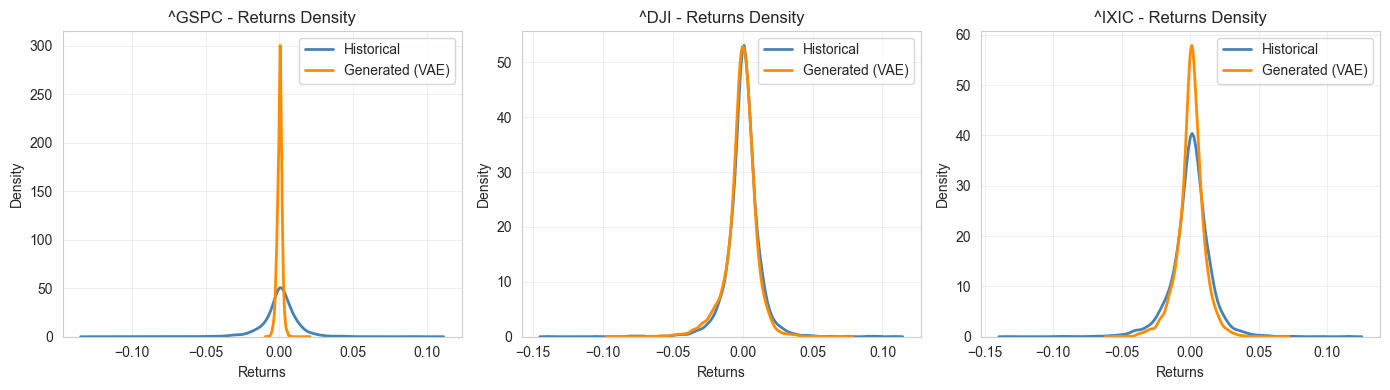

In [6]:
# Compare distributions with KDE-only density curves
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
top_assets = indices[:3]

for idx, col in enumerate(top_assets):
    sns.kdeplot(historical_returns[col], ax=axes[idx], color='steelblue', linewidth=2, label='Historical')
    sns.kdeplot(scenarios_df[col], ax=axes[idx], color='darkorange', linewidth=2, label='Generated (VAE)')
    axes[idx].set_title(f'{col} - Returns Density')
    axes[idx].set_xlabel('Returns')
    axes[idx].set_ylabel('Density')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/05_scenario_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

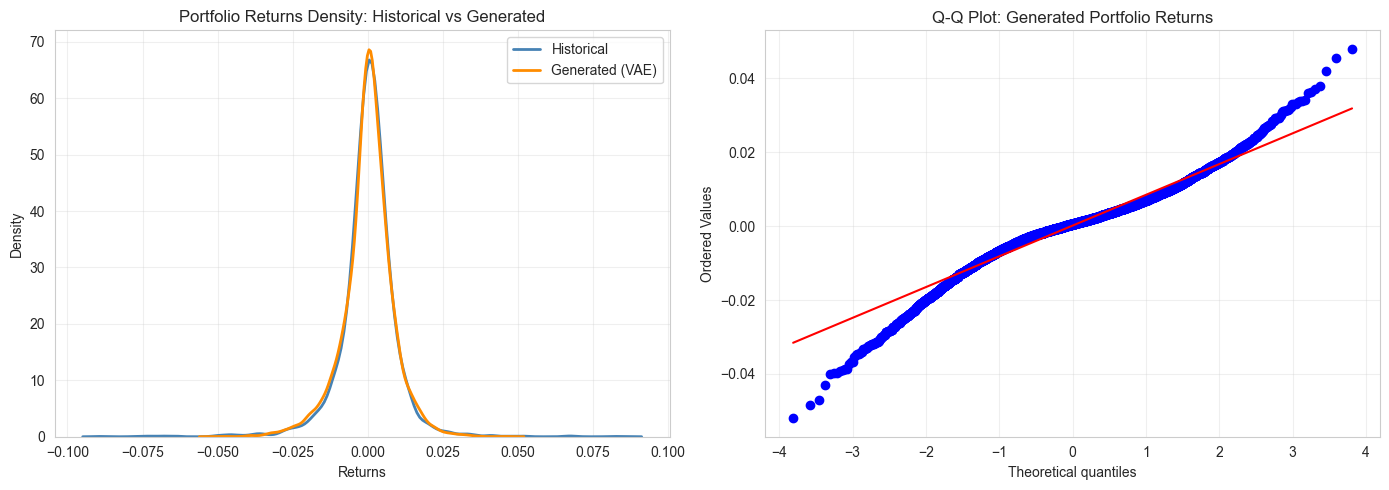

In [7]:
# Compare portfolio-level returns with KDE-only density curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Portfolio weights
weights_norm = config.weights / config.weights.sum()

# Calculate portfolio returns
historical_portfolio = np.dot(historical_returns.values, weights_norm)
generated_portfolio_returns = np.dot(scenarios_df.values, weights_norm)

# Historical vs Generated scenarios
sns.kdeplot(historical_portfolio, ax=axes[0], color='steelblue', linewidth=2, label='Historical')
sns.kdeplot(generated_portfolio_returns, ax=axes[0], color='darkorange', linewidth=2, label='Generated (VAE)')
axes[0].set_title('Portfolio Returns Density: Historical vs Generated')
axes[0].set_xlabel('Returns')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(generated_portfolio_returns, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Generated Portfolio Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/06_portfolio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Statistical Tests

In [8]:
from scipy import stats

# Kolmogorov-Smirnov test
print("Kolmogorov-Smirnov Test (H0: same distribution):")
print("-" * 60)

for col in indices:
    ks_stat, p_value = stats.ks_2samp(historical_returns[col], scenarios_df[col])
    print(f"{col:15} | KS-stat: {ks_stat:.4f} | p-value: {p_value:.4f}")

print("\nNote: Higher p-value means distributions are more similar")

Kolmogorov-Smirnov Test (H0: same distribution):
------------------------------------------------------------
^GSPC           | KS-stat: 0.3439 | p-value: 0.0000
^DJI            | KS-stat: 0.0541 | p-value: 0.0000
^IXIC           | KS-stat: 0.0744 | p-value: 0.0000
^FTSE           | KS-stat: 0.2746 | p-value: 0.0000
^FCHI           | KS-stat: 0.0546 | p-value: 0.0000
^GDAXI          | KS-stat: 0.0197 | p-value: 0.1803
^SSMI           | KS-stat: 0.0375 | p-value: 0.0003
^N225           | KS-stat: 0.0263 | p-value: 0.0272
^HSI            | KS-stat: 0.0618 | p-value: 0.0000
^AEX            | KS-stat: 0.0426 | p-value: 0.0000
SPY             | KS-stat: 0.0303 | p-value: 0.0068
QQQ             | KS-stat: 0.0739 | p-value: 0.0000
DIA             | KS-stat: 0.0692 | p-value: 0.0000
IWM             | KS-stat: 0.0740 | p-value: 0.0000
IVV             | KS-stat: 0.0385 | p-value: 0.0002
EFA             | KS-stat: 0.0378 | p-value: 0.0003
EEM             | KS-stat: 0.0221 | p-value: 0.0962
VTI   

## 6. Calculate Portfolio Returns

In [9]:
# Portfolio weights
weights = config.weights / config.weights.sum()

print(f"Portfolio weights: {dict(zip(indices, weights))}")

# Calculate portfolio returns
historical_portfolio = np.dot(historical_returns.values, weights)
generated_portfolio = np.dot(scenarios_df.values, weights)

print(f"\nHistorical portfolio returns - Mean: {historical_portfolio.mean():.6f}, Std: {historical_portfolio.std():.6f}")
print(f"Generated portfolio returns  - Mean: {generated_portfolio.mean():.6f}, Std: {generated_portfolio.std():.6f}")

Portfolio weights: {'^GSPC': 0.016666666666666666, '^DJI': 0.016666666666666666, '^IXIC': 0.016666666666666666, '^FTSE': 0.016666666666666666, '^FCHI': 0.016666666666666666, '^GDAXI': 0.016666666666666666, '^SSMI': 0.016666666666666666, '^N225': 0.016666666666666666, '^HSI': 0.016666666666666666, '^AEX': 0.016666666666666666, 'SPY': 0.016666666666666666, 'QQQ': 0.016666666666666666, 'DIA': 0.016666666666666666, 'IWM': 0.016666666666666666, 'IVV': 0.016666666666666666, 'EFA': 0.016666666666666666, 'EEM': 0.016666666666666666, 'VTI': 0.016666666666666666, 'XLF': 0.016666666666666666, 'XLK': 0.016666666666666666, 'XLE': 0.016666666666666666, 'XLY': 0.016666666666666666, 'XLP': 0.016666666666666666, 'XLI': 0.016666666666666666, 'XLB': 0.016666666666666666, 'XLV': 0.016666666666666666, 'XLU': 0.016666666666666666, 'IYR': 0.016666666666666666, 'VOX': 0.016666666666666666, 'EWJ': 0.016666666666666666, 'EWU': 0.016666666666666666, 'EWG': 0.016666666666666666, 'EWQ': 0.016666666666666666, 'EWC'

## 7. Plot Portfolio Returns

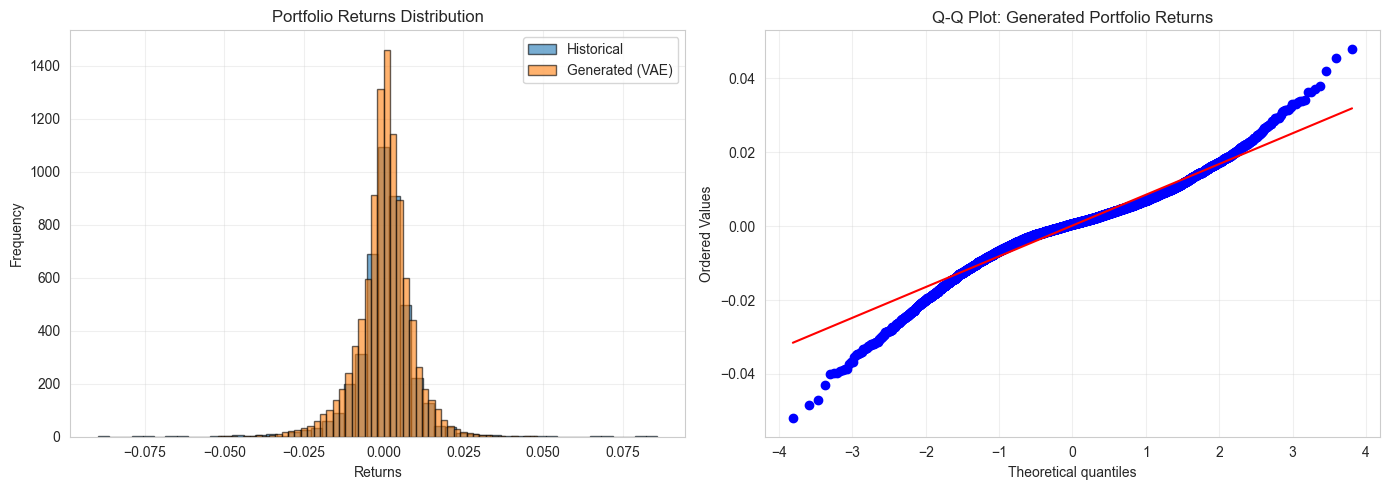

In [10]:
# Plot portfolio returns comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(historical_portfolio, bins=50, alpha=0.6, label='Historical', edgecolor='black')
axes[0].hist(generated_portfolio, bins=50, alpha=0.6, label='Generated (VAE)', edgecolor='black')
axes[0].set_title('Portfolio Returns Distribution')
axes[0].set_xlabel('Returns')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Q-Q plot
stats.probplot(generated_portfolio, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Generated Portfolio Returns')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/06_portfolio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Scenarios for VaR Calculation

In [11]:
# Save scenarios
scenarios_df.to_csv('../results/scenarios.csv', index=False)

# Save portfolio returns (safe with mismatched lengths)
portfolio_data = pd.concat(
    [
        pd.Series(historical_portfolio, name='historical'),
        pd.Series(generated_portfolio, name='generated'),
    ],
    axis=1,
 )
portfolio_data.to_csv('../results/portfolio_returns.csv', index=False)

print("Scenarios saved!")
print(f"  - scenarios.csv: {scenarios_df.shape}")
print(f"  - portfolio_returns.csv: {portfolio_data.shape}")
print("  - Note: length mismatch handled with NaN padding")

Scenarios saved!
  - scenarios.csv: (10000, 60)
  - portfolio_returns.csv: (10000, 2)
  - Note: length mismatch handled with NaN padding
